<a href="https://colab.research.google.com/github/carlosprr29/ai-progetto-spagnoli/blob/main/notebooks/01_3_Exploratory_Data_Analysis_FUSION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =================================================================
# PHASE: Dataset Fusion & Final Exploratory Data Analysis (EDA)
# =================================================================

# 1. INSTALLATION AND LOADING OF LIBRARIES
# -----------------------------------------------------------------
import pandas as pd
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from google.colab import drive
from wordcloud import WordCloud


In [ ]:
# 2. LOADING WELFake FROM HUGGING FACE
# -----------------------------------------------------------------
print(" Loading WELFake dataset from Hugging Face...")
# Using your preferred 'davanstrien/WELFake' source
dataset_raw = load_dataset("davanstrien/WELFake")
df_welfake = pd.DataFrame(dataset_raw['train'])

# Initial cleaning: remove nulls and assign source tag
df_welfake = df_welfake.dropna(subset=['text', 'label']).drop_duplicates()
df_welfake_sub = df_welfake[['text', 'label']].copy()
df_welfake_sub['source'] = 'WELFake'
print(f" WELFake loaded: {len(df_welfake_sub)} rows.")

In [ ]:
# 3. LOADING ISOT FROM GOOGLE DRIVE
# -----------------------------------------------------------------
print(" Loading ISOT dataset from Google Drive...")
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Paths for ISOT CSV files
path_true = "/content/drive/MyDrive/Project_IA/data/True.csv"
path_fake = "/content/drive/MyDrive/Project_IA/data/Fake.csv"

df_true = pd.read_csv(path_true)
df_fake = pd.read_csv(path_fake)

# Assign labels and concatenate
df_true['label'] = 0
df_fake['label'] = 1
df_isot = pd.concat([df_true, df_fake]).reset_index(drop=True)

# Define and apply Reuters bias removal (Regex cleaning)
def remove_reuters_bias(text):
    # Removes patterns like "WASHINGTON (Reuters) -" at the start
    pattern = r'^.*?\(Reuters\)\s*-\s*|^.*?\s*-\s*'
    return re.sub(pattern, '', str(text), count=1)

print(" Cleaning ISOT source bias...")
df_isot['text'] = df_isot['text'].apply(remove_reuters_bias)
df_isot_sub = df_isot[['text', 'label']].copy()
df_isot_sub['source'] = 'ISOT'
print(f" ISOT loaded and cleaned: {len(df_isot_sub)} rows.")

In [ ]:
# 4. FINAL FUSION AND EXPORT
# -----------------------------------------------------------------
# Merging both dataframes into a unified corpus
df_fusion = pd.concat([df_welfake_sub, df_isot_sub]).reset_index(drop=True)
print(f" FUSION COMPLETE: {len(df_fusion)} total articles available.")

# Save to Drive to avoid reloading in future sessions
fusion_output_path = "/content/drive/MyDrive/Project_IA/data/final_fused_dataset.csv"
df_fusion.to_csv(fusion_output_path, index=False)
print(f" Fused dataset saved to: {fusion_output_path}")

In [ ]:
# 5. GLOBAL CLASS BALANCE ANALYSIS
# -----------------------------------------------------------------
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_fusion, x='label', palette='viridis')
plt.title('Global Label Distribution (Fused Dataset)', fontsize=14)
plt.xticks([0, 1], ['Real News (0)', 'Fake News (1)'])

# Add percentage labels
total = len(df_fusion)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2 - 0.1, p.get_height() + 500), fontweight='bold')

plt.show()

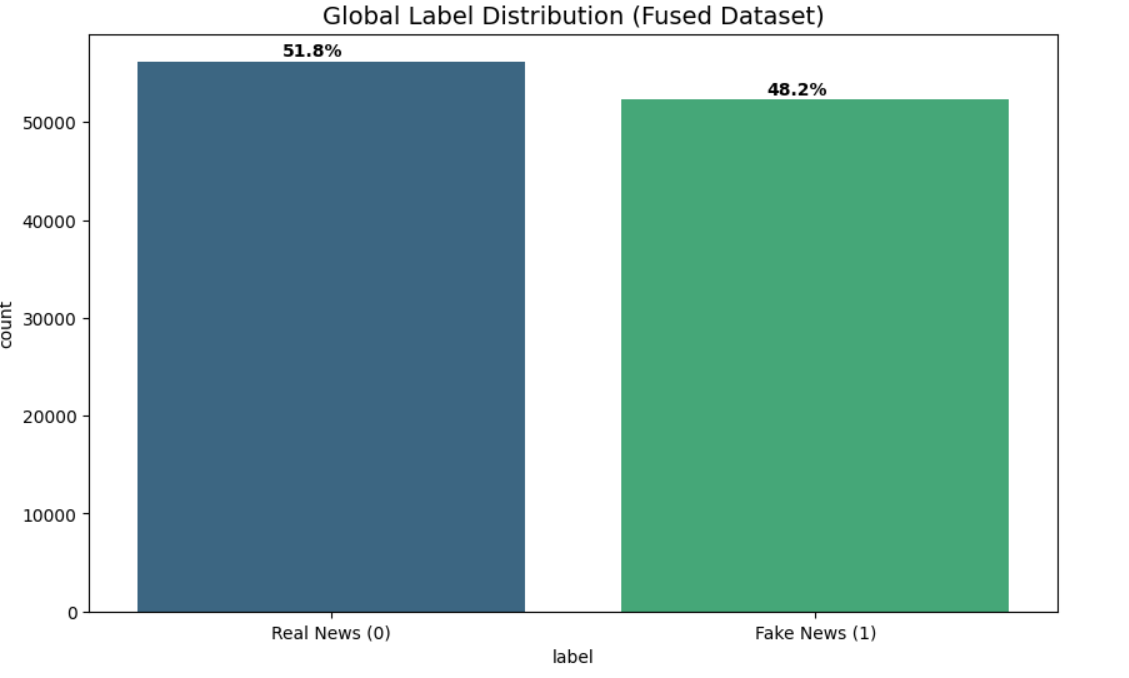

In [ ]:
# 6. CONTENT EXPLORATION (Sampling)
# -----------------------------------------------------------------
print("\n Displaying 10 random news items from the dataset:")
display(df_fusion.sample(10))

|index|text|label|source|
|---|---|---|---|
|11480|CLEVELAND/NEW YORK - Bracing for a general election fight with Donald Trump, Democratic presidential front-runner Hillary Clinton and her allies are putting resources into industrial states such as Ohio and Pennsylvania to try to block Trump from making inroads with working-class voters there\. Labor leaders, progressive groups and Democratic operatives told Reuters in interviews that they took seriously Trump’s appeal with white working-class voters and were studying how to respond to his promises to create jobs and negotiate better trade deals\. The desire to stop the presumptive Republican presidential nominee from wresting away the support of unionized workers has even led a group organized to back Bernie Sanders, Labor for Bernie, to consider its next steps if Sanders does not win the Democratic nomination\. “It may well be our task to work hard to reach out to our \(labor union\) members who support Trump and begin an important dialogue,” said Rand Wilson, a staunch Sanders supporter and Labor for Bernie spokesman\. The Rust Belt, which includes Ohio, Pennsylvania, Michigan, Illinois, Wisconsin, Indiana and West Virginia, has suffered heavy job losses in sectors such as autos, coal and steel that have faced fierce competition from abroad\. The region, home to many unionized workers, has been a stronghold for Democrats\. The exceptions are socially conservative West Virginia, which has gone Republican in the past four presidential elections, and Indiana, which has gone Democratic only twice since 1940\. Ohio has switched back and forth\. Trump has aggressively courted working-class voters ahead of the Nov\. 8 election to succeed Democratic President Barack Obama\. He has criticized the North American Free Trade Agreement \(NAFTA\) and promised to rip up the Trans-Pacific Partnership \(TPP\) trade deal\. He has also said he will consider raising the minimum wage and backing higher taxes on the wealthy\.  On Monday, Trump sought to backtrack from those comments on taxes\. “Now if I increase it on the wealthy, that means they’re still going to be paying less than they are paying now,” he told CNN\. “I’m talking about increasing it from my \(original\) tax proposal\.” Trump campaign manager Corey Lewandowski told Reuters the campaign was targeting industrial states like Pennsylvania and Michigan, which have voted Democratic in presidential elections since 1992\. Working America, an advocacy group affiliated with the AFL-CIO labor federation, is expanding operations in states like Ohio and Pennsylvania and plans to open an office in Wisconsin\. Its first mission is talking to voters about jobs and the economy and trying to gauge where they are leaning in the presidential race\. Later in the campaign, the group will work more aggressively to win over voters\. In Ohio, the Democratic Party has doubled its field operation over the past month, thanks to an infusion of cash raised by the Clinton campaign for the national and state parties\. Clinton, who has a strong lead over Sanders but has yet to secure the Democratic nomination, has already hired state directors in Ohio and Pennsylvania\. Working America field director Soren Norris knocked on doors on the west side of Cleveland last week as part of an effort to gauge voter sentiment\. At the first house, Tamara Phillips, 44, told Norris she was not enthusiastic about either Clinton or Trump but that she would vote for the New York businessman if forced to choose\. Phillips, who works in publishing, said taxes on her commission income rose during former President Bill Clinton’s administration\. But she said she had reservations about Trump’s “gruff” demeanor\. With an eye toward voters across the Rust Belt, Clinton visited Appalachia last week with stops in West Virginia and Ohio\. She apologized for previous statements related to shutting down the coal industry and told protesters she was committed to solving their economic problems even if they did not support her\. Union activists said their strategy for undercutting Trump’s support would be pointing out discrepancies in his positions\. His comment that he is open to raising the minimum wage comes after he said in a November debate that “wages are too high” and that an increase would hurt the economy\. Although Trump rails against trade deals and businesses that move operations to Mexico, critics say that items such as ties and suits in his clothing line were made in China\. “The best way to go after Trump is to make him run against himself,” said political strategist Brad Bannon, who advises labor unions\. Tom Buffenbarger, a Clinton surrogate to labor and the past president of the machinists’ union, said Democrats would have “a lot of fun” highlighting Trump’s inconsistencies, although he acknowledged the Republican candidate presented a threat in some Rust Belt states\. “Are we concerned about the industrial states in the upcoming election?” Buffenbarger said\. “Yeah, Donald Trump’s done a good job complaining about the trade deal while he continues to ship work from the U\.S\. to China\.” |0|WELFake|
|57074|She had us at the hat toss\. Mary Richards was a modest Midwestern girl, to be sure, but she had style, and she had spunk, as her new boss, Lou Grant, pointed out the day she walked into the   newsroom in her white   boots, a pleated miniskirt and those impeccable manners\. When she threw her tam in the air during the show’s opening credits, we knew she was thrilled to be single and on her own in the big city of Minneapolis\. But as the series unfolded, and we watched Mary Tyler Moore’s most famous character dress for work in the uniform of career women all over the country  —   the clingy knit dresses, the matching   pantsuits, the Evan Picone separates  —   she showed us her heart was in that newsroom\. Ms\. Moore died on Wednesday in Greenwich, Conn\. \[ Read Mary Tyler Moore’s obituary &#124; 5 great episodes to stream \] There was a cultural sweet spot in the 1970s, as the old social mores unraveled \(along with the “sweater girl”\) and women flexed new muscles as working women, divorced women, women commited to the single life, newly conscious women  —   to use the parlance of the   feminist playbook  —   and fashion reflected the fluidity of that time\. As women were reinventing themselves, fashion helped them along\. Clothing, even in the office, was colorful and personal those jersey dresses and knit pantsuits moved with the body\. And they were womanly\. Mary’s inherent authority  —   that moral compass  —   was never compromised by the fact that she dressed in the basic idiom of her gender\. \(By the next decade, that freedom would be snuffed out, and working girls would ape the rigid suits of their male competitors, but that’s another story\.\) And like all working women, she wore the same outfit more than once, and so her wardrobe became as familiar as our own\. Her predecessor, Ann Marie of “That Girl,” played by Marlo Thomas, was our first television singleton, but paired from the   with her boyfriend, Donald\. She made her debut in the 1960s, a period that for women on the small screen was still the dark ages\. Mary Richards had boyfriends, but they were ancillary to her real life, which played out at work\. Looking back at both shows, the clothing displayed the maturation, or the evolution, of the female television avatar\. Ann Marie dressed almost like a child in the show’s early episodes, in the cartoonish, youthquake fashions of Mary Quant and others, which Ms\. Thomas brought with her from London\. The bunny hat notwithstanding, Mary Richards looked like a   \. “The Mary Tyler Moore Show” always embraced the real world, and as it unfurled, that world grew a little darker, as did Mary Richards’ clothes\. In the final episode, the newsroom is under assault: Ratings are low, and Mary and the gang are fired\. But Mary is armored\. Clad in a navy blue jumpsuit, like a fighter pilot, her hair cropped to her shoulders, she is strong enough to say goodbye and turn out those lights\.|0|WELFake|
|102031|up each other in caring for the citizens of OTHER countries while Swedish retirees, school children, handicapped and other vulnerable categories of people are thorougly ignored\. Violence is exploding\. Jihadist Trojan horses are flowing through the porous border along with the tens of thousands ID-less refugees\.But what makes me the most pessimistic about Sweden s future is how the social fabric itself has been undermined\.Now, to be clear, it is my opinion that modest immigration is healthy for society and beneficial for trade, cultural development and so forth\. Protectionism as a concept is counter-productive, while free trade and the ability for skilled labor to go where they re in demand is beneficial for everyone\.Having said that, what Sweden is doing is something completely different\. The once homogenous population has been forever altered by a rapid and massive addition of people from vastly different cultures and value-systems\. 26,8% of the population is now foreign-born or with at least one foreign-born parent, and the national census bureau estimates that some 150 000 per year will arrive to the country of just 9,8 million residents\.There simply is no possible way to absorb and assimilate such volumes of people, period\. Then you are merely creating ethnic enclaves, which due to incompatible language, culture and job skills become ghettos, which in turns brews crime, misery and extremism\. Once the inflow has exceeded the capacity for absorbtion, further immigration only makes the problem worse\.It s like someone having read that a cup of green tea per day is healthy, so they make it a policy to chug four gallons per day, every day\. It s a good thing overdone to the extreme until it becomes toxic\.Then you have the Swedish school system\. There really is no nice way to put it; it s a complete disaster\. The minister of education is a man-boy who spends his time making Youtube-videos showing heart-signs with his hands to boost school results, while university-level students can t read and comprehend the course literature\.Education minister Gustav FridolinSince there is a delay in the changes in the school system, it is only in recent years the full impact of the knowledge-averse  progressive  school system is starting to be felt\. Hard facts are largely irrelevant; the important thing is to sit in a group and discuss things until a consensus is reached\. But with no hard facts to base the conclusions on, it becomes an exercise in futility because it s all random assumptions and opinions\. As a university-level history student \(\!\) was quoted as saying in newspaper Svenska Dagbladet the other day:  Why would all these dates matter? Who cares in what order things happened? That s not exactly fertile soil for creating the researchers and engineers of the future\.Financially, Sweden is an oddity in that it never had its real estate correction when Lehman Bros went belly-up and the housing market everywhere in the West crashed\. Sweden just kept steaming ahead, which means housing is ridiculously overinflated\. In Stockholm, the real estate prices increased 19% and in Gothenburg 24% in the last 12 months alone   from an already sky-high level\.Tear-down abandoned house from 1932 with small, unremarkable lot in the outskirts of Stockholm\. Current bid: 7,5 million SEK, or close to $900,000\.As a result, personal debt of the Swedish population is at an all-time high\. To keep all this afloat the normal mortgage interest rates are at 2% with central bank Riksbanken at -0,25%, and yet a significant portion of the borrowers are hanging by a thread\. If and when foreign banks and investors decide it s time to turn their backs on Sweden \(as happened in the early 1990s\) there s going to be a lot of pain\.Then you have the financial obligations going forward\. Like much of the western world, there is a demographic change where fewer tax-paying adults are to support a glut of retirees\. What makes it especially dire for Sweden is that in addition to the old Swedes, there s also a ton of elderly immigrants that are granted  family visas  based on younger relatives having been granted asylum\. They ve never paid a dime in taxes, yet enter the system with full benefits from day one\. In theory, this would be made up for by the younger relatives working and paying taxes\. Sadly, this is not the case; while ethnical Swedes have a 82% employment rate, immigrants only have 57% with non-Europeans coming in at just 51%\.If Sweden was a person, it d be like the guy with three mortgages, seven maxed-out credit cards and four collection agencies chasing him that just signed a lease for a brand new BMW X6\. Simply put, there s a lot of red ink in the future; it just hasn t been fully realized yet\.Finally, there s the sorry state of the Swedish defense\. After decades of constant slashing of the defense budget, the extent of Swedish ambition is to stall an invader for a week in a limited area\. This with war raging in Europe, Russian missiles pointed at Sweden in Kaliningrad, and Russian submarines and bomber jets openly thumbing their nose at Sweden as they intrude on Swedish territory on a regular basis\. The power vacuum in Scandinavia is so tangible you can almost hear a sucking sound as you fly over it\. This, too, will require massive investments when the penny finally drops amongst Swedish politicians\.So while I can t claim to be any kind of authority on macroeconomics or social predictive models, I see red lights across the board\.In some ways, I d compare the country to a farm\. Previously, Sweden acted like a sensible farmer and planted wheat here, carrots there, potatoes over there et cetera, by implementing free schooling, sound infrastructure investments, state-financed research and so forth\. A few decades later, they reaped the rewards and climbed the prosperity ladder\.In the late 1960s, this pragmatic line was abandoned as leftist idealist Olof Palme took over\. But there was plenty to harvest from previous years, so Sweden continued to be the land of milk and honey for a good long while\. Then things started drying up, and the process has been one of gradual erosion and decline since the 1990s\.The famous Swedish health care system is a good example\. 120 000 hospital beds in the late 1960s became 20 000 today\. Cancer patients are put on waiting lists for months\. Entire emergency wards shut down for summer\. The crumbling Swedish railroad system is another symptom I examined in-depth last year\. The aforementioned defense that now consist of about three fat generals and a rusty rifle \(bullets withheld for budgetary reasons\)\.A sensible farmer would see the problems for what they are and hurry to plant new seeds, so as to return to bountiful harvests of wheat, carrots, potatoes etc\. Instead, the Swedish politicians goes by dogma and plants what they think SHOULD grow\. So they plant M & Ms, hot dogs and pretzels\. The results won t be fully evident for a few years yet, but as the last reserves of the old harvests are depleted, things will get  Interesting\.From what I can see, there simply is no plausible scenario where these social tensions and future financial committments will not lead to a downward spiral of hardship and strife\. I hope I m wrong\. I really do, because I have friends and family I care about that will remain here to see it all play out\.But I won t\. I ll be back in the US being mad at Obama for being a lying scumbag\. And if Trump manages to get elected in 2016? Whoo boy\. A racist ignoramus who takes pride in the worst qualities of a cranky eight-year old should make George  Dumbo  Bush seem like Abe Lincoln by comparison\. So every country has its problems\. USA has its corrupt yokel in office, just as Sweden has Stefan L fven\. Via: The Sweden Report |1|ISOT|
|63887|U\.S\. Democratic Senator Al Franken announced his resignation on Thursday after facing a series of sexual misconduct allegations, and Republican Representative Trent Franks also said he was stepping down as he too was hit with ethics charges\.  Franken, buffeted for weeks by sexual harassment charges and under pressure from party colleagues, said on the Senate floor he would leave in a few weeks, although he denied some of the allegations against him and questioned others\. The 66-year-old former comedian from Minnesota had been seen as a rising star in the Democratic Party\. “I know in my heart that nothing I’ve done as a senator - nothing - has brought dishonor on this institution,” he said\. “Nevertheless, today I am announcing that in the coming weeks, I will be resigning as a member of the United States Senate\.” Hours later, Franks announced his resignation after two former staff members complained about discussions he had with them about his efforts to find a surrogate mother\. “I deeply regret that my discussion of this option and process in the workplace caused distress,” said Franks, who was first elected to his Arizona congressional seat in 2002 and is an outspoken opponent of abortion\.  Franks said in a statement that he and his wife “have long struggled with infertility\.” The developments came with Congress already held in low regard by voters\. According to a Reuters/Ipsos poll, only 20 percent approved of the way Congress was handling its job, with 70 percent disapproving\. In recent weeks, charges of sexual misconduct have taken down prominent people in the worlds of entertainment, media and politics\. It is somewhat rare for members of the Senate or House of Representatives to resign from office, but veteran Democratic Representative John Conyers also resigned earlier this week amid sexual harassment accusations that he has denied\. The House Ethics Committee said on Thursday it was investigating yet another lawmaker\. Blake Farenthold, a Republican representative from Texas, faces allegations of sexual harassment, discrimination and retaliation involving a former female staff member\. Franken has the highest profile of the lawmakers hit by allegations in the past few weeks\.  Reuters has not independently verified the accusations against Franken, Franks, Conyers or Farenthold\. Franken’s seat will initially be filled by a Democrat appointed by Minnesota’s Democratic governor, meaning the  Republicans’ slim majority in the Senate will not change\. Allegations that Franken had groped and tried to kiss women without their consent began to surface three weeks ago\. He initially said he was embarrassed and ashamed by his behavior but would not resign\.  But the majority of his Democratic colleagues in the Senate called on Wednesday for his resignation after a new allegation, denied by Franken, hit the news\.  “Some of the allegations against me are simply not true\. Others I remember very differently,” Franken said on Thursday\.  Striking a tone of defiance, he also sought to contrast himself with two prominent Republicans - President Donald Trump and Senate candidate Roy Moore\. “I, of all people, am aware that there is some irony in the fact that I am leaving while a man who has bragged on tape about his history of sexual assault sits in the Oval Office and a man who has repeatedly preyed on young girls campaigns for the Senate, with the full support of his party,” he said\. Trump was heard bragging about kissing and forcibly touching women in a 2005 videotape that surfaced last year as he was running for the White House\. He apologized for the remarks, but called them private “locker-room talk” and said he had not done the things he talked about\.  Trump also denied allegations at that time by at least 12 women of sexual advances and groping in the past\. Moore, who is running for the Senate in Alabama in a special election on Tuesday, has been accused by several women of sexual assault or misconduct when they were teenagers and Moore was in his early 30s\. Moore, 70, has denied the accusations, which Reuters has not independently verified\. Trump has backed Moore, but Senate Republicans have been cooler toward his candidacy\. In pressing Franken to step aside, Democrats have tried to capture the moral high ground and draw a distinction between their party and Republicans\.         “In every workplace in America, including the U\.S\. Senate, we must confront the challenges of harassment and misconduct,” said Amy Klobuchar, Franken’s fellow Democratic senator from Minnesota\.     Similarly, House Republican Speaker Paul Ryan said on Thursday he had told Franks that he should resign\. A special election will be scheduled to determine a replacement for Franks\. While a Democrat will be appointed initially to replace Franken, his departure could complicate the party’s efforts to maintain or build on the 46 Senate seats they hold\. Two independent senators also vote with the Democrats\. Republicans are defending eight seats in the congressional elections in November 2018 but Democrats will be defending 26 if Minnesota holds a special election for Franken’s seat\. The election to fill Franken’s seat could be close\. When he ran in 2008, the race was decided after an extensive recount, with Minnesota’s Supreme Court weighing in\.  In the 2016 presidential election, Democrat Hillary Clinton won the state by less than 2 percentage points\. |0|ISOT|
|103663|duty Los Angeles police officer and other passengers were able to stop the man and secure him in a seat\. It was all kind of surreal,  said Penny Lorenzen, a passenger on the flight\.Her husband was among those who got up to try to stop the man\. It took seconds,  said Lee Lorenzen, of Orange County, Calif\.  He was pushing against the cart and a bunch of guys grabbed him\. They found some duct tape\. There were pillows and blankets\. And they taped him to his chair\.   Hawaii News Now A man was subdued after he tried to breach the cockpit of an American Airlines flight to Honolulu, a source familiar with the situation told ABC News\.American Airlines said in a statement that law enforcement met the plane upon landing in Honolulu following a  disturbance  on the flight\. The plane was escorted by two F-22 fighter jets for the duration of the flight following the disturbance, U\.S\. Pacific Command said in a statement\.  ABC NewsA source at the TSA told ABC News that the man was waiting for the bathroom near the cockpit when a flight attendant asked him to sit down\. He had a laptop with him and appeared to try the cockpit door before he was subdued, the source said\.The man, whose identity was not immediately available, was escorted off American Airlines Flight 31, after it landed safely at 11:35 a\.m\. Hawaii Standard Time, according to a statement from the airline\.A government source confirmed that he had been loitering near the restroom and was carrying a laptop\. Flight attendants asked him to return to his seat and he refused\.He then seemed to lunge towards the cockpit door\. That s when several passengers subdued him\.He was arrested on the ground by the FBI\.The flight, which originated from Los Angeles, was to arrive in Honolulu about noon\. The flight departed from Los Angeles International Airport at 8:34 a\.m\. local time\.  NBC Los AngelesLATEST: 2 F-22 fighter jets escorted American Airlines Flight 31 to Honolulu Int l Airport due to disturbance on board, Pacific Command says pic\.twitter\.com/Ee8zTg4PN3  ABC News \(@ABC\) May 19, 2017|1|ISOT|
|96644|long FBI investigation during which the 25-year-old met with undercover FBI agents who were posing as ISIS operatives and expressed his desire to reap mass casualties in the United States\.Hester, a father of two, served a short stint in the Army beginning in 2012\. He faced a series of disciplinary issues and received a general discharged in 2013\.Three years later, Hester had converted to Islam, changed his name, and was posting anti-government messages to social media\.The Army veteran was arrested last week and was charged with attempting to provide material support to a foreign terrorist organization\.In late January, Hester met with one undercover FBI agent posing as an ISIS contact who asked the veteran to purchase a series of items that could be used to make bombs, including 9-volt batteries, duct tape, copper wire, and nails\. Hester brought the bomb supplies to a later meeting and handed them over to the undercover agent\.Hester s final meeting with the undercover agents was last week, where he brought a box of nails to be used as shrapnel for the bombs\. He told agents on Friday that it felt  good to help strike back at the true terrorist\. First on social media, then during face-to-face meetings with an undercover FBI employee, this defendant repeatedly expressed his intent to engage in acts of violent jihad against the United States,  U\.S\. Attorney for the Western District of Missouri Tammy Dickinson said in a statement\.  He believed he was part of an ISIS-sponsored terrorist attack that would result in the deaths and injuries of many innocent victims\.   WFB |1|ISOT|
|79826|Masoud Barzani, who spent decades leading the long-oppressed Kurds, confirmed on Sunday he was stepping down as president of the Kurdistan Regional Government after his drive for independence backfired\. After decades of struggle, critics say Barzani made one of his biggest mistakes by pushing hard for a Sept\. 25 referendum\.  Kurds voted overwhelmingly for independence, but won little sympathy outside their region\. As well as the Iraqi government, Turkey and Iran threatened to take tough action against any move towards secession, fearing it would encourage their own restive Kurdish populations to follow suit\.  The United States and other Western powers joined the chorus of opposition to the vote\. The Baghdad government rejected it as illegal and sent troops to seize the oil city of Kirkuk, which the Kurds regard as the heart of any future homeland\. In just a few hours, the city the Kurds regard as sacred was gone, along with other Kurdish-held territory across the north\.  Some accused Barzani of having led his people to disaster\. For many years, he had used cunning and patience to help the Kurds survive long years of brutality under Saddam Hussein\. After the U\.S\.-led invasion that toppled Saddam in 2003, Barzani became a central figure in the drive to create an autonomous Kurdish state in northern Iraq\. Kurdish leaders kept their territory relatively free of the sectarian bloodshed that plagued most of Iraq\. Western oil executives flocked to the region seeking deals\.   Kurds showed their military capability by joining Iraqi government troops and Iranian-backed paramilitary forces to drive Islamic State militants out of Mosul\. Confident that the time was right for an independent homeland, Barzani pursued the referendum\.  It resulted in overwhelming support for secession\. But the joy was short-lived as Iraqi government forces and Shi ite paramilitaries shattered the Kurds  dreams with a series of lightning military advances\.  Barzani was born in 1946, soon after his legendary father founded a party to fight for the rights of Iraqi Kurds\.  Deeply influenced by his father, Mulla Mustafa Barzani, known as the Lion of Kurdistan, Masoud Barzani joined the Kurdish guerrilla forces known as the Peshmerga at the age of 16 and gained fighting experience in the mountains\. The younger Barzani would become familiar with one of the popular themes in Kurdish history - betrayal by regional and Western powers\. Exiled and dying of cancer in a Washington hospital in 1976, Mulla Mustafa lamented that he had ever trusted the United States\.   A year earlier, Mulla Mustafa had been fighting a guerrilla war against Baghdad backed by Iran s pro-Western shah, but he was left high and dry when then-U\.S\. Secretary of State Henry Kissinger brokered a deal that allowed Saddam to crush the Kurds\. During the 1980-88 Iran-Iraq war, Masoud Barzani allied the Kurdistan Democratic Party that he had inherited from his father with Tehran once more\. It did not go well\. Some 8,000 Barzani tribesmen were rounded up and paraded through Baghdad before being executed\. In Saddam s words:  They went to hell\.  Despite the massacres, and Iraqi chemical attacks, Barzani retained enough of a fighting force to respond to President George Bush s appeal for an uprising during the 1991 Gulf War\. Taking Bush at his word, the Kurds rose up against Saddam,  and Barzani and his Peshmerga - known as  those who face death  - came down from the mountains to join the uprising and capture several cities in the north\. But the victorious allies balked at the prospect of a Kurdish split from Baghdad and did nothing to stop Saddam s troops and helicopter gunships from crushing the rebellion\.   While more than a million Kurds fled to Turkey and Iran, many dying of hunger and exposure on the way, Barzani stayed to fight on\.  He was saved by a U\.S\. and British no-fly zone established over the north in 1991 which allowed him and his Kurdish rival, Jalal Talabani, to retake the area\.   This was followed by the longest period of Kurdish autonomy in modern history, but it was scarred by civil war between Barzani and Talabani s Patriotic Union of Kurdistan in the mid-1990s\.   Barzani invited Iraqi government tanks into the region in 1996 to seize the regional capital Erbil, sending not only Talabani, but dozens of CIA personnel and their local employees fleeing before them\. Talabani died barely a week after last month s referendum\.  Barzani s exit will leave the Kurds lacking direction, with their two main leaders gone\. |0|ISOT|
|9272|Amazon stock has skyrocketed this week as shares rose above $900 for the first time on Tuesday CNN Money reports\. \[Amazon stock is riding high with shares gaining 7 percent this week alone and 20 percent overall this year\. This values Amazon at around $430 billion, twice the market value of one of its major rivals Walmart which is worth around $220 billion\. Currently, the only companies worth more than Amazon are Apple, Alphabet, and Microsoft\. Amazon is now worth more than both Facebook and the Warren   Berkshire Hathaway,  This surge in Amazon’s stock price comes after the announcement last week that the company would be buying the Middle Eastern   site Souq\. com\. Amazon reportedly purchased the company which had been previously valued at around $1 billion for the price of $650 million\. Amazon’s stock is now trading at 125 times the companies estimated earnings this year and 75 times the companies projected profits for next year\. Despite the high price of the stock, financial data and software company FactSet still considers the stock a good buy\. Two dozen analysts have estimated the stock price target to rise above the current price with seven analysts putting it above $1, 000\. Daniel Salmon of BMO Capital Markets raised his price estimation on Monday to $1, 200 while Shyam Patil of Susquehanna Financial Group raised his price target to $1250\. These estimations are approximately 40 percent higher than the current market price, if these predictions are proven true, then Amazon could soon hold a market value of nearly $600 billion\. Considering the company’s rapid expansion into technology with their Amazon Alexa home device and it’s Sponsored Products business, Amazon could soon also be dominating the tech and world in the near future\. Lucas Nolan is a reporter for Breitbart News covering issues of free speech and online censorship\. Follow him on Twitter @LucasNolan or email him at lnolan@breitbart\. com|0|WELFake|
|17186|As Hillary Clinton assailed Donald J\. Trump on Thursday for fanning the flames of racism embraced by the “” the community of activists that tends to lurk anonymously in the internet’s dark corners could hardly contain its glee\. Mrs\. Clinton’s speech was intended to link Mr\. Trump to a fringe ideology of conspiracies and hate, but for the leaders of the   the attention from the Democratic presidential nominee was a moment in the political spotlight that offered a new level of credibility\. It also provided a valuable opportunity for   and recruiting\. Jared Taylor, editor of the white nationalist publication American Renaissance,   Mrs\. Clinton’s remarks, questioning her praise of establishment Republicans and eagerly anticipating her discussion of his community\. “Come on, Hillary,” he wrote\. “Talk about Alt Right\. ” In an ode to Mr\. Trump’s characterization of Jeb Bush, Mr\. Taylor described her speech as “low energy\. ” Other white nationalists mocked Mrs\. Clinton, saying she sounded like a neoconservative and a “grandma,” while welcoming the publicity\. Mr\. Trump has publicly kept his distance from the   but his critics have accused him of offering subtle cues to invite its support\. His appointment of Stephen K\. Bannon, the head of Breitbart News, to be chief executive of his campaign was cheered by   members who are avid readers of the Breitbart website\. The   claims to support the preservation of white culture in the United States, and many of its members want to see an overhaul of the entire political system\. However, its views are widely seen as white supremacist and  \. Many who align themselves with   philosophies say that they do not subscribe to all of Mr\. Trump’s policies, but that electing him would be a step in the right direction because of his “America First” worldview and his hard line on immigration\. This week, some expressed disappointment that Mr\. Trump appeared to be softening his tone on deporting people who are in the country illegally\. Richard B\. Spencer, the president of the   National Policy Institute, who is credited with coming up with the name “” pushed back against claims that the group promotes violence and said in a statement that there was a double standard at play\. “While Hillary  Co\. condemn the    —   nonviolent activists seeking social change, largely through a vibrant internet presence  —   she allows noted supporters of terror to attend her rallies and has never once disavowed the actions of domestic terrorists associated with Black Lives Matter,” Mr\. Spencer said\. Mrs\. Clinton’s public criticism of the   could turn out to be a boon for the movement, and its members did their best to capitalize on the moment\. Some, in an effort to show a lighthearted side, circulated footage of Mr\. Taylor playing the saxophone at the group’s most recent conference\. The white nationalist website VDare published a “What Is the  ?” video and blasted out a   pitch warning, “Hillary wants to ignite a witch hunt against the   because she knows we are finally starting to make an impact on the public’s thinking about immigration\. ” And the Stormfront forum set up an online thread for potential new members\. After Mrs\. Clinton’s speech, one group of white nationalists convened a   videoconference that was broadcast on YouTube\. The consensus was that Mrs\. Clinton was “toothless” and “lackluster,” and they expressed disappointment that she had not mentioned   leaders by name\. She made reference only to David Duke, the former Klansman whose support Mr\. Trump was slow to disavow\. Although the   tried to put its best foot forward, there was plenty of venom directed at Mrs\. Clinton, and the conspiracy theories ran wild\. A popular attack was the continuing effort to raise questions about her health\. By addressing the   in such a prominent setting, Mrs\. Clinton ran the risk of helping its cause\. But Richard Cohen, the president of the Southern Poverty Law Center, which tracks hate groups, dismissed the idea that Mrs\. Clinton was doing the public a disservice by drawing attention to the  \. “I think every public official ought to denounce racism, and that is what Secretary Clinton did,” Mr\. Cohen said, noting that the   ideology opposes the notion that all people are equal\. Referring to the term “” which was trending on Twitter, he added, “It is a fancy, almost antiseptic term for white supremacy in the digital world\. ”|0|WELFake|
|90568|called  evidence  there is from the right wing that racism is over\.Featured image via video screen capture|1|ISOT|

In [ ]:
# 7. TEXT LENGTH ANALYSIS (Checking for Bias Dilution)
# -----------------------------------------------------------------
df_fusion['text_len'] = df_fusion['text'].apply(lambda x: len(str(x)))

plt.figure(figsize=(10, 6))
sns.histplot(data=df_fusion[df_fusion['text_len'] < 5000], x='text_len', hue='label', kde=True, palette='magma')
plt.title('Text Length Distribution (FUSED DATASET)')
plt.xlabel('Number of Characters')
plt.show()

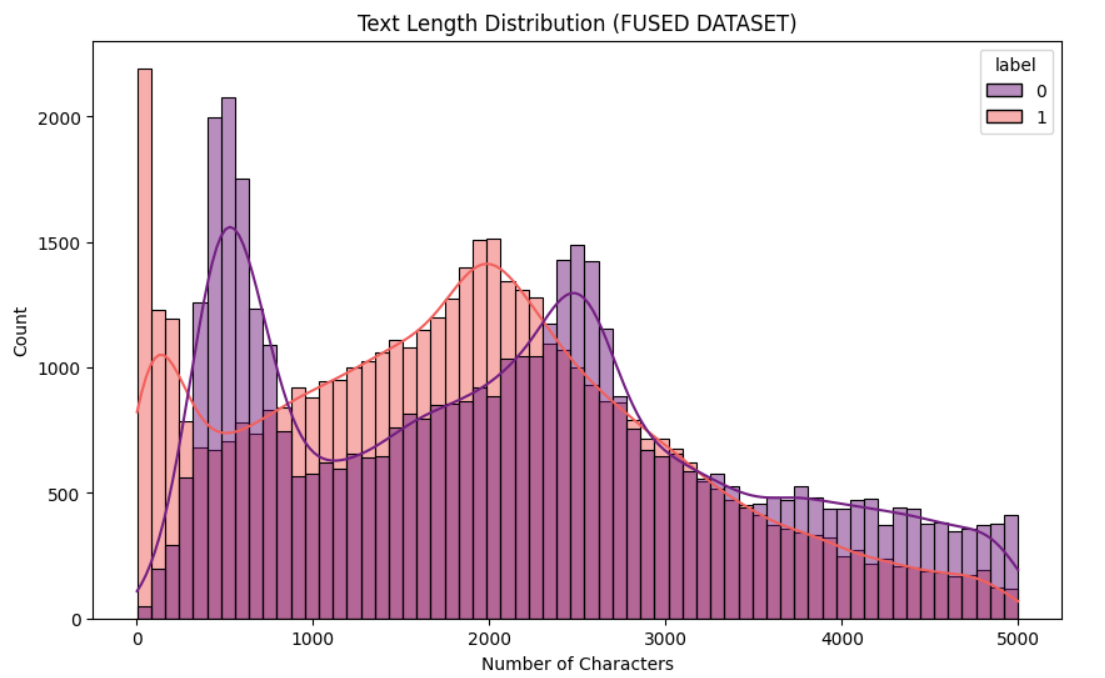

In [ ]:
# 8. FINAL WORDCLOUDS (Visual Validation)
# -----------------------------------------------------------------
def generate_fused_cloud(label, title, cmap):
    text = " ".join(df_fusion[df_fusion['label'] == label]['text'].astype(str))
    wc = WordCloud(width=800, height=400, background_color='white', max_words=100, colormap=cmap).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title, fontsize=16)
    plt.axis('off')
    plt.show()



In [ ]:
generate_fused_cloud(0, "Keywords in FUSED REAL News", "viridis")
generate_fused_cloud(1, "Keywords in FUSED FAKE News", "inferno")

In [ ]:
# 9. FUSION BIAS TRACKER (Keyword Dilution)
# -----------------------------------------------------------------
def check_fusion_bias(term):
    subset = df_fusion[df_fusion['text'].str.contains(term, case=False, na=False)]
    if not subset.empty:
        dist = subset['label'].value_counts(normalize=True) * 100
        print(f"\n BIAS CHECK for: '{term}'")
        print(f"Appearances: {len(subset)} | Distribution: {dist.to_dict()}")
    else:
        print(f"\nTerm '{term}' not found.")

check_fusion_bias("Reuters")
check_fusion_bias("said")
check_fusion_bias("one")
check_fusion_bias("people")
check_fusion_bias("Trump")
check_fusion_bias("Clinton")

BIAS CHECK for: 'Reuters'
Appearances: 27028 | Distribution: {0: 97.19180109516059, 1: 2.808198904839426}

 BIAS CHECK for: 'said'
Appearances: 76655 | Distribution: {0: 66.53447263714042, 1: 33.46552736285957}

 BIAS CHECK for: 'one'
Appearances: 75679 | Distribution: {0: 50.172438853578925, 1: 49.82756114642107}

 BIAS CHECK for: 'people'
Appearances: 48115 | Distribution: {0: 50.05715473345111, 1: 49.94284526654889}

 BIAS CHECK for: 'Trump'
Appearances: 50408 | Distribution: {1: 50.216235518171715, 0: 49.78376448182828}

 BIAS CHECK for: 'Clinton'
Appearances: 19463 | Distribution: {1: 61.64003493808765, 0: 38.35996506191235}

In [ ]:
# 9. EXPORT FOR TRAINING
# -----------------------------------------------------------------
# Extracting 50 samples for manual QC
df_fusion.sample(n=50, random_state=42).to_csv("/content/drive/MyDrive/Project_IA/data/fusion_samples_check.csv", index=False)

# Save the full fused dataset
df_fusion.to_csv("/content/drive/MyDrive/Project_IA/data/final_fused_dataset.csv", index=False)
print(" Final Fused Dataset saved successfully for training.")

# Conclusion
After fusing these datasets, we’ve built a massive library of 110,000 articles. It’s definitely much stronger than using just one source, but let’s be honest: it’s not perfect. Here’s the reality of what we’re dealing with:

- The "Reuters" Shadow: Even though we scrubbed the headers, "Reuters" still shows up in 27,000 articles, and almost all of them are "Real." There’s a high chance our AI will try to take the easy way out and just learn that "Reuters = Truth." It’s a shortcut we have to watch out for.

- Stuck in 2016: We can't ignore that this data is obsessed with the 2016 US election. Mentioning "Clinton" still leans heavily towards the "Fake" label (61%). This means our model isn't necessarily becoming a "Truth Detector"—it’s becoming an expert on how people lied or exaggerated back then.

- Style over Facts: Looking at the samples, many "Fake" articles are actually just very aggressive opinion pieces. Our BERT model is likely going to learn how to spot sensationalist tone and toxic language rather than actually fact-checking the world.


We’ve done a great job "diluting" the obvious traps, but the model will still inherit some political ghosts. We aren't building an infallible oracle; we’re training a tool to recognize the "vibe" of misinformation. It’s a huge step forward, but we have to stay critical of its results, especially when it faces news from 2026 that doesn't look like a 2016 tweet.